# 01g — LLM Model Analysis (Phase 1)

Post-hoc analysis of the Phase-1 model-selection results, the LLM counterpart to
`ml_models/04_Model_Analysis.ipynb`. Same lens (feature reliance + error analysis)
so the two pipelines compare on equal footing.

Structure:
1. **Brief model comparison** — all candidates on the headline metrics, and why
   GPT-5.4 was chosen.
2. **GPT-5.4 — feature reliance** — which features actually drive its decisions,
   overlaid against XGBoost's SHAP reliance from notebook `04`.
3. **GPT-5.4 — error analysis** — where it fails, how that overlaps with XGBoost,
   and what it costs.

- Reads predictions already on disk (`01a_predictions.csv`) — **no API calls.**
- Runs on the shared **`tuning_sample`**; **`test_batch` is never touched.**


In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from llm_utils import load_llm_sample, LLM_FEATURES, FEATURE_DESCRIPTIONS

RESULTS_LLM = '../../../data/results/llm'
RESULTS_ML  = '../../../data/results/ml'

metrics = pd.read_csv(f'{RESULTS_LLM}/01a_metrics.csv')
preds   = pd.read_csv(f'{RESULTS_LLM}/01a_predictions.csv')
sample  = load_llm_sample()
y_true  = sample['loan_status'].values     # 1 = Fully Paid, 0 = Charged Off
print('Models in 01a:', sorted(preds['model'].unique()))
print(f'Sample = {len(sample)} loans | default rate = {1-y_true.mean():.2f}')


Models in 01a: ['Claude Opus 4.8', 'Claude Sonnet 4.6', 'GPT-5.4', 'Gemini 2.5 Pro', 'Gemini 3.5 Flash']
Sample = 100 loans | default rate = 0.15


## Part 1 — Brief Model Comparison

Context only: how the candidates rank, to justify the GPT-5.4 choice carried into the
rest of Phase 1. The risk class is `Charged Off`, so F1/recall on it matter more than
accuracy. (Detailed cost + reasoning fingerprints live in `01f`.)

,label,accuracy,f1_charged_off,recall_charged_off,auc
1,GPT-5.4 (no_desc),0.810,0.387,0.400,0.624
9,Gemini 2.5 Pro (with_desc),0.640,0.379,0.733,0.680
2,GPT-5.4 (with_desc),0.780,0.353,0.400,0.617
8,Gemini 2.5 Pro (no_desc),0.550,0.328,0.733,0.610
10,Claude Sonnet 4.6 (no_desc),0.515,0.314,0.733,NaN
4,Claude Opus 4.8 (with_desc),0.690,0.311,0.467,NaN
7,Gemini 3.5 Flash (with_desc),0.640,0.308,0.533,NaN
6,Gemini 3.5 Flash (no_desc),0.630,0.302,0.533,NaN
3,Claude Opus 4.8 (no_desc),0.670,0.298,0.467,NaN
0,XGBoost (structured),0.650,0.286,0.467,NaN


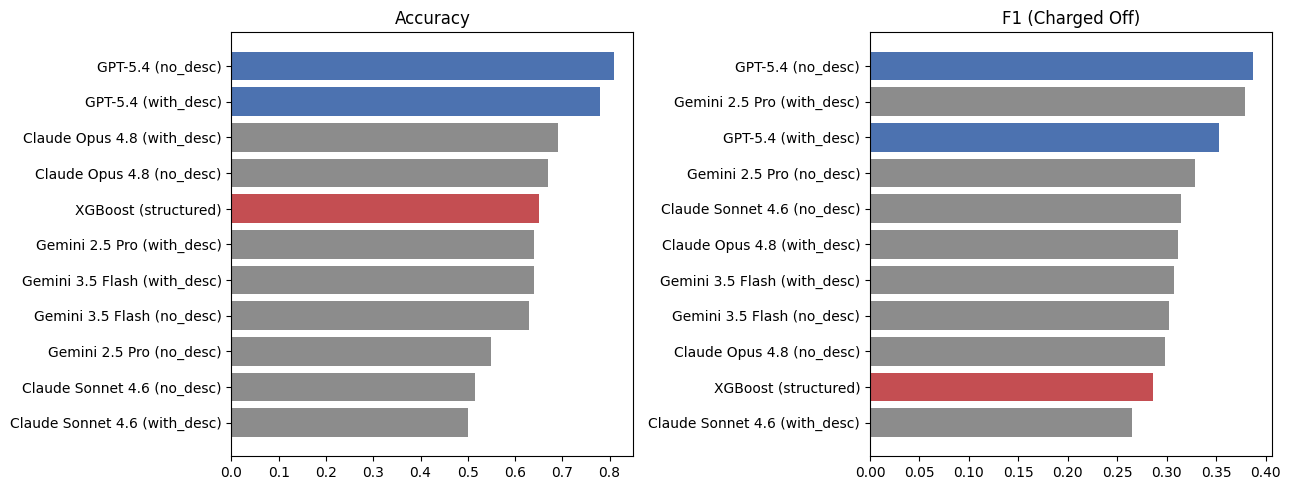

Red = XGBoost baseline, Blue = GPT-5.4. GPT-5.4 (no_desc) is the chosen config carried forward (best F1/accuracy balance; see 01b/01c/01d/01f).


In [2]:
cmp = metrics.copy()
cmp['label'] = cmp['model'] + ' (' + cmp['condition'] + ')'
view = cmp[['label', 'accuracy', 'f1_charged_off', 'recall_charged_off', 'auc']].sort_values(
    'f1_charged_off', ascending=False).round(3)
display(view)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, ttl in [(axes[0], 'accuracy', 'Accuracy'), (axes[1], 'f1_charged_off', 'F1 (Charged Off)')]:
    d = cmp.sort_values(col)
    colors = ['#C44E52' if 'XGBoost' in l else ('#4C72B0' if 'GPT-5.4' in l else '#8C8C8C')
              for l in d['label']]
    ax.barh(d['label'], d[col], color=colors); ax.set_title(ttl)
plt.tight_layout(); plt.show()
print('Red = XGBoost baseline, Blue = GPT-5.4. GPT-5.4 (no_desc) is the chosen config '
      'carried forward (best F1/accuracy balance; see 01b/01c/01d/01f).')


## Part 2 — GPT-5.4 Feature Reliance

The LLM gives no SHAP values, so we fit a **global surrogate**: a transparent model
trained to reproduce GPT-5.4's *predictions* from the loan features. The surrogate's
feature importances reveal which signals the LLM's decisions implicitly track. We
report the surrogate's **fidelity** (how well it mimics the LLM) so the reliance read
is trustworthy, and overlay it against XGBoost's SHAP reliance from notebook `04`.

We analyse the chosen config: **GPT-5.4, no_desc.**

In [3]:
# Build a numeric feature matrix over the 30 source features for the surrogate.
ORDINAL = {
    'term': {' 36 months': 36, ' 60 months': 60},
    'emp_length': {'< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
                   '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9,
                   '10+ years': 10},
    'grade': {g: i for i, g in enumerate('ABCDEFG', start=1)},
}
NOMINAL = ['home_ownership', 'verification_status', 'purpose',
           'initial_list_status', 'application_type']

def encode_for_surrogate(df):
    df = df.copy()
    if 'mths_since_last_delinq' in df:
        df['has_past_delinq'] = df['mths_since_last_delinq'].notna().astype(int)
        df['mths_since_last_delinq'] = df['mths_since_last_delinq'].fillna(999)
    if 'issue_d' in df and 'earliest_cr_line' in df:
        df['credit_history_years'] = (pd.to_datetime(df['issue_d']) -
                                      pd.to_datetime(df['earliest_cr_line'])).dt.days / 365.25
    cols = {}
    for f in LLM_FEATURES:
        if f not in df: continue
        if f in ORDINAL:
            cols[f] = df[f].map(ORDINAL[f]) if not pd.api.types.is_numeric_dtype(df[f]) else df[f]
        elif f == 'sub_grade':
            cols[f] = df[f].astype('category').cat.codes      # ordinal A1..G5
        elif f in NOMINAL:
            for col, s in pd.get_dummies(df[f], prefix=f).items():
                cols[col] = s
        else:
            cols[f] = pd.to_numeric(df[f], errors='coerce')
    X = pd.DataFrame(cols).fillna(0.0)
    return X

def source_of(col):
    if col in LLM_FEATURES: return col
    cands = [f for f in LLM_FEATURES if col.startswith(f + '_')]
    return max(cands, key=len) if cands else col

X_surr = encode_for_surrogate(sample)
print('Surrogate matrix:', X_surr.shape)


Surrogate matrix: (100, 41)


Surrogate fidelity (5-fold acc reproducing GPT-5.4 no_desc labels): 0.90
(GPT-5.4 predicts Fully Paid 84% of the time -> majority-class baseline 84%)


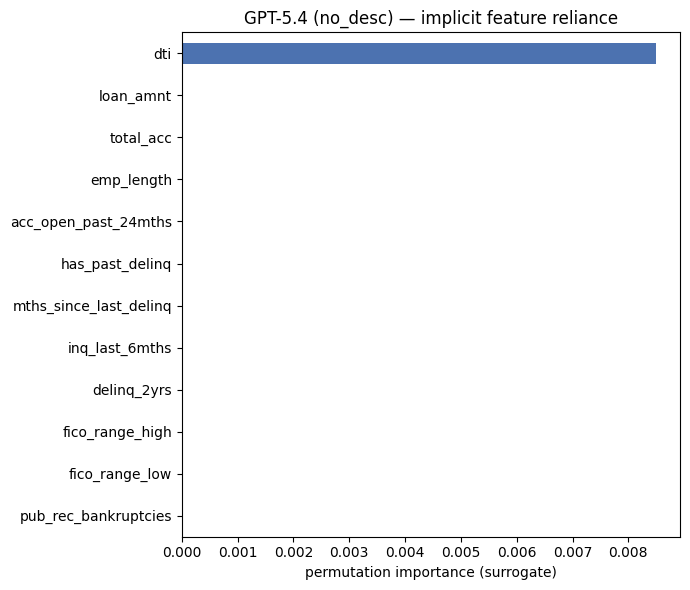

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score

def reliance_for(model_name, condition):
    block = preds[(preds['model'] == model_name) & (preds['desc_tag'] == condition)].reset_index(drop=True)
    yhat = block['llm_pred'].values
    m = ~np.isnan(yhat)
    X, yhat = X_surr[m].reset_index(drop=True), yhat[m].astype(int)

    fidelity = np.nan
    if len(np.unique(yhat)) > 1:
        fidelity = cross_val_score(RandomForestClassifier(n_estimators=400, random_state=42),
                                   X, yhat, cv=5, scoring='accuracy').mean()
    surr = RandomForestClassifier(n_estimators=400, random_state=42).fit(X, yhat)
    pi = permutation_importance(surr, X, yhat, scoring='accuracy', n_repeats=20, random_state=42)

    agg = {}
    for col, w in zip(X.columns, pi.importances_mean):
        agg[source_of(col)] = agg.get(source_of(col), 0.0) + float(w)
    imp = pd.Series(agg).sort_values(ascending=False)
    return imp, fidelity, yhat.mean()

gpt_imp, fid, base = reliance_for('GPT-5.4', 'no_desc')
print(f'Surrogate fidelity (5-fold acc reproducing GPT-5.4 no_desc labels): {fid:.2f}')
print(f'(GPT-5.4 predicts Fully Paid {base*100:.0f}% of the time -> majority-class baseline {max(base,1-base)*100:.0f}%)')

fig, ax = plt.subplots(figsize=(7, 6))
gpt_imp.head(12)[::-1].plot.barh(ax=ax, color='#4C72B0')
ax.set_xlabel('permutation importance (surrogate)')
ax.set_title('GPT-5.4 (no_desc) — implicit feature reliance'); plt.tight_layout(); plt.show()


Top features for GPT-5.4 vs their XGBoost SHAP rank:


,gpt_rank,xgb_rank,gpt_importance,xgb_mean_abs_shap
dti,1,6,0.0085,0.0907
acc_open_past_24mths,16,4,0.0000,0.1627
term,16,2,0.0000,0.2425
sub_grade,16,19,0.0000,0.0315
revol_util,16,11,0.0000,0.0469
revol_bal,16,9,0.0000,0.0548
purpose,16,16,0.0000,0.0408
pub_rec_bankruptcies,16,25,0.0000,0.0062
pub_rec,16,24,0.0000,0.0077
open_acc,16,15,0.0000,0.0413


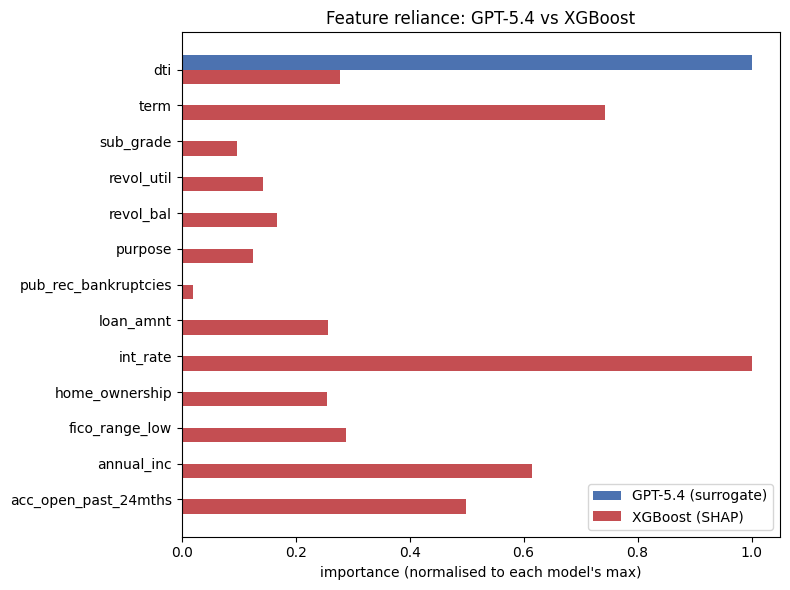

Spearman rank correlation of feature reliance (GPT-5.4 vs XGBoost): 0.20


In [5]:
# Overlay against XGBoost SHAP reliance (notebook 04). Both ranked over source
# features; we compare the rank each model gives every feature.
xgb = pd.read_csv(f'{RESULTS_ML}/04_feature_importance.csv').set_index('feature')
ov = pd.DataFrame({
    'gpt_importance': gpt_imp,
    'xgb_mean_abs_shap': xgb['mean_abs_shap'],
}).fillna(0.0)
ov['gpt_rank'] = ov['gpt_importance'].rank(ascending=False).astype(int)
ov['xgb_rank'] = ov['xgb_mean_abs_shap'].rank(ascending=False).astype(int)
top = ov.sort_values('gpt_rank').head(12)
print('Top features for GPT-5.4 vs their XGBoost SHAP rank:')
display(top[['gpt_rank', 'xgb_rank', 'gpt_importance', 'xgb_mean_abs_shap']].round(4))

# normalised side-by-side of the union of each model's top features
u = pd.Index(ov.sort_values('gpt_rank').head(8).index).union(
    ov.sort_values('xgb_rank').head(8).index)
norm = ov.loc[u, ['gpt_importance', 'xgb_mean_abs_shap']].copy()
norm = norm / norm.max()
norm = norm.sort_values('gpt_importance')
fig, ax = plt.subplots(figsize=(8, 6))
y = np.arange(len(norm)); h = 0.4
ax.barh(y + h/2, norm['gpt_importance'], h, label='GPT-5.4 (surrogate)', color='#4C72B0')
ax.barh(y - h/2, norm['xgb_mean_abs_shap'], h, label='XGBoost (SHAP)', color='#C44E52')
ax.set_yticks(y); ax.set_yticklabels(norm.index)
ax.set_xlabel('importance (normalised to each model\'s max)')
ax.set_title('Feature reliance: GPT-5.4 vs XGBoost'); ax.legend(); plt.tight_layout(); plt.show()

rho = ov['gpt_rank'].corr(ov['xgb_rank'], method='spearman')
print(f'Spearman rank correlation of feature reliance (GPT-5.4 vs XGBoost): {rho:.2f}')


## Part 3 — GPT-5.4 Error Analysis

Where GPT-5.4 (no_desc) fails, sliced by segment, plus whether it fails on the **same
loans** as XGBoost (if errors overlap heavily, the two models share blind spots).
Cost constants match the `01f` ledger (LGD €5,000 / missed default; €2,000 / false
rejection).

In [6]:
g = preds[(preds['model'] == 'GPT-5.4') & (preds['desc_tag'] == 'no_desc')].reset_index(drop=True)
err = sample.copy()
err['y_true'] = g['actual'].values
err['llm_pred'] = g['llm_pred'].values
err['xgb_pred'] = g['xgb_pred'].values
err = err.dropna(subset=['llm_pred']); err['llm_pred'] = err['llm_pred'].astype(int)

err['outcome'] = np.select(
    [(err.y_true == 0) & (err.llm_pred == 0), (err.y_true == 0) & (err.llm_pred == 1),
     (err.y_true == 1) & (err.llm_pred == 0), (err.y_true == 1) & (err.llm_pred == 1)],
    ['TP (caught default)', 'FN (missed default)', 'FP (false rejection)', 'TN (good approved)'],
    default='?')

LGD_COST, FP_COST = 5000, 2000
n_fn = (err.outcome == 'FN (missed default)').sum()
n_fp = (err.outcome == 'FP (false rejection)').sum()
print(f'GPT-5.4 missed defaults (FN): {n_fn}  -> credit loss ~ EUR {n_fn*LGD_COST:,}')
print(f'GPT-5.4 false rejections (FP): {n_fp}  -> lost profit ~ EUR {n_fp*FP_COST:,}')
print(f'Approx. error cost on {len(err)} loans: EUR {n_fn*LGD_COST + n_fp*FP_COST:,}\n')
print('Errors by grade:'); display(pd.crosstab(err['grade'], err['outcome']))


GPT-5.4 missed defaults (FN): 9  -> credit loss ~ EUR 45,000
GPT-5.4 false rejections (FP): 10  -> lost profit ~ EUR 20,000
Approx. error cost on 100 loans: EUR 65,000

Errors by grade:


outcome,FN (missed default),FP (false rejection),TN (good approved),TP (caught default)
grade,,,,
A,0,0,14,0
B,7,0,31,1
C,2,5,16,0
D,0,1,11,2
E,0,3,3,3
F,0,1,0,0


In [7]:
# Overlap of GPT-5.4 vs XGBoost errors.
err['llm_wrong'] = (err.y_true != err.llm_pred)
err['xgb_wrong'] = (err.y_true != err.xgb_pred)
both  = (err.llm_wrong & err.xgb_wrong).sum()
llm_o = (err.llm_wrong & ~err.xgb_wrong).sum()
xgb_o = (~err.llm_wrong & err.xgb_wrong).sum()
print(f'Wrong by BOTH models:      {both}')
print(f'Wrong by GPT-5.4 only:     {llm_o}')
print(f'Wrong by XGBoost only:     {xgb_o}')
print(f'GPT-5.4 total errors: {err.llm_wrong.sum()} | XGBoost total errors: {err.xgb_wrong.sum()}')
shared = both / max(err.llm_wrong.sum(), 1)
print(f'\n{shared*100:.0f}% of GPT-5.4 errors are also XGBoost errors '
      '(high overlap => shared blind spots on the structured features).')


Wrong by BOTH models:      16
Wrong by GPT-5.4 only:     3
Wrong by XGBoost only:     19
GPT-5.4 total errors: 19 | XGBoost total errors: 35

84% of GPT-5.4 errors are also XGBoost errors (high overlap => shared blind spots on the structured features).


## Takeaways

- GPT-5.4's chosen config (no_desc) is profiled with the same feature-reliance and
  error lens as XGBoost in `04`.
- The reliance overlay + rank correlation quantify **how much the two model families
  agree on what matters** — the structured counterpart to the prose fingerprints in
  `01f`.
- The error overlap shows whether GPT-5.4 and XGBoost fail on the same loans.
- See `02d` for the same analysis across prompt *variants* (model held fixed).